No shift returns

In [1]:
import sf_quant.data as sfd
import sf_quant.optimizer as sfo
import sf_quant.backtester as sfb
import sf_quant.performance as sfp

import polars as pl
import datetime as dt

In [2]:
weights=pl.scan_parquet(r'/home/porter77/sf_fall_2025/sf-quant-labs/labs/weights/10k-tfidf-cos-sim-fwd-ret-stop-words')
weights=weights.collect()
weights

date,barrid,weight
date,str,f64
2004-01-02,"""USA1151""",0.0
2004-01-02,"""USA11I1""",0.0
2004-01-02,"""USA12I1""",0.0
2004-01-02,"""USA1371""",0.0
2004-01-02,"""USA14R1""",0.0
…,…,…
2024-12-31,"""USBQNC1""",0.000527
2024-12-31,"""USBQND1""",-0.000118
2024-12-31,"""USBQO11""",0.000289


In [3]:
start = weights["date"].min()
end = weights["date"].max()

columns = ["date", "barrid", "return"]

returns = sfd.load_assets(start=start, end=end, in_universe=True, columns=columns)

returns = returns.sort("barrid", "date")

joined = (
        weights.join(returns, on=["date", "barrid"], how="left")
        .with_columns(
            pl.col("return").truediv(100),
        )
    )

joined = joined.sort(["barrid", "date"])

joined=joined.with_columns(
    pl.col('return').shift(-2).over('barrid').alias('fwd_ret')
)
joined=joined.with_columns(
    (pl.col('fwd_ret')*pl.col('weight')).alias('weighted_ret')
)
joined

date,barrid,weight,return,fwd_ret,weighted_ret
date,str,f64,f64,f64,f64
2013-07-31,"""USA06Z1""",0.000117,-0.001595,-0.001582,-1.8473e-7
2013-08-01,"""USA06Z1""",0.000086,0.009585,0.022187,0.000002
2013-08-02,"""USA06Z1""",0.000098,-0.001582,-0.024806,-0.000002
2013-08-05,"""USA06Z1""",0.000098,0.022187,-0.081081,-0.000008
2013-08-06,"""USA06Z1""",0.000098,-0.024806,0.00173,1.6907e-7
…,…,…,…,…,…
2024-12-24,"""USBQOR1""",-0.000984,0.025872,-0.05108,0.00005
2024-12-26,"""USBQOR1""",-0.00094,0.04293,-0.042663,0.00004
2024-12-27,"""USBQOR1""",-0.000917,-0.05108,-0.016749,0.000015


In [4]:
result = (
        joined.group_by("date")
        .agg([
            pl.col('weighted_ret').sum().alias("return"),
        ])
        .sort("date")
    )

result

date,return
date,f64
2004-01-02,0.0
2004-01-05,0.0
2004-01-06,0.0
2004-01-07,0.0
2004-01-08,0.0
…,…
2024-12-24,0.002478
2024-12-26,0.000265
2024-12-27,0.001411


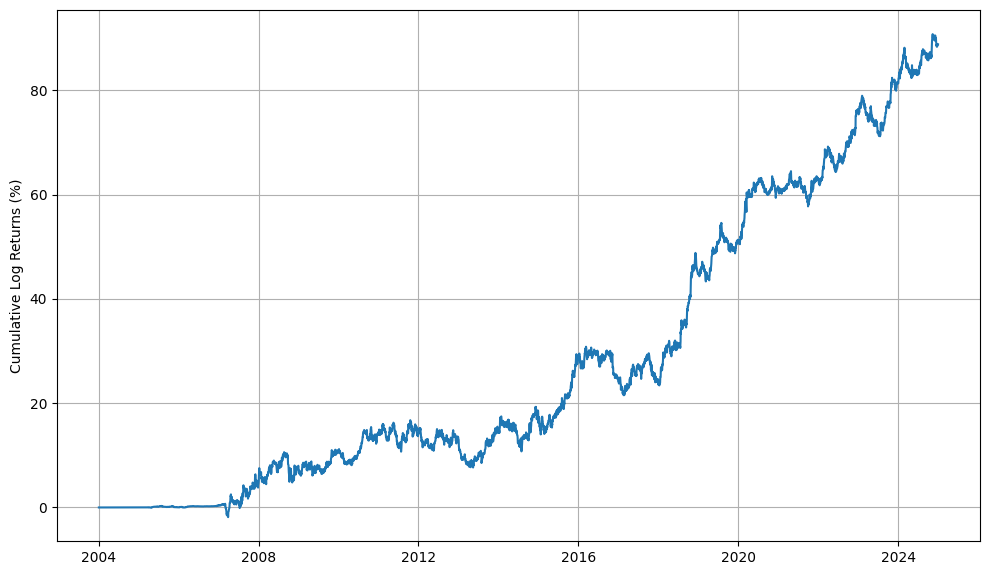

In [5]:
sfp.generate_returns_chart(returns=result,title='',log_scale=True)


In [6]:
sfp.generate_returns_summary_table(returns=result)

Count,Mean Return (%),Volatility (%),Total Return (%),Sharpe
u32,f64,f64,f64,f64
5285,4.39,5.51,143.06,0.8


In [7]:
labels_w_spread=['return']

import pandas as pd
import statsmodels.formula.api as smf

ff5=(pl.read_csv(r'/home/porter77/sf_fall_2025/sf-quant-labs/ff5_daily.csv')
    # 1) lowercase all column names
    .rename({c: c.lower() for c in pl.read_csv(r'/home/porter77/sf_fall_2025/sf-quant-labs/ff5_daily.csv').columns})
    # 2) convert YYYYMM -> Date (YYYY-MM-01)
    .with_columns(
        pl.col("date")
        .cast(pl.Utf8)
        .str.strptime(pl.Date, format="%Y%m%d", strict=False)
        .alias("date")
    )
)
#make the month date month end rather than month start
# ff5=ff5.with_columns(
#     (pl.col('date').dt.month_end()).alias('date')
# )

#ff5 uses percentage, need to convert to decimal divide all numeric by 100
ff5 = ff5.with_columns(
    pl.selectors.numeric() / 100
)


ff5_merged=result.join(ff5,on=['date'],how='inner')
#getting excess return for each port and then making them cols
for bin in labels_w_spread:
    try:
        ff5_merged=ff5_merged.with_columns(
            (pl.col(bin)-pl.col('rf')).alias(f'ex_{bin}')
        )
    except Exception:
        continue

#rename mkt-rf to just mkt
ff5_merged=ff5_merged.rename({'mkt-rf':'mkt'})

ff5_merged_pd=ff5_merged.to_pandas()
ff5_merged_pd = ff5_merged_pd.sort_values('date')

#sort ff5_merged_pd
ff5_merged_pd.sort_values('date')
#now do the ff5 regressions

residuals_dict = {}

results_list = []
for b in labels_w_spread:
    try:
        if b=='spread': # we do not need to use ex_spread because (p4-rf) - (p0-rf), the rf will cancel so we can just do p4-p0
            model = smf.ols(
                formula=f'spread ~ mkt + smb + hml + rmw + cma',
                data=ff5_merged_pd
            )
            res = model.fit()
            results_list.append(res)

            alpha = res.params["Intercept"]
            residuals_dict[b] = res.resid +alpha #adding alpha back in
        else:
            model = smf.ols(
                formula=f'ex_{b} ~ mkt + smb + hml + rmw + cma',
                data=ff5_merged_pd
            )
            res = model.fit()
            results_list.append(res)
            alpha = res.params["Intercept"] 
            residuals_dict[b] = res.resid +alpha #adding the alpha back in
    except Exception:
        continue

#chats code to make it into a reg table
def results_to_df(results_list, col_names=None, params=None, dec_coef=4, dec_t=2):
    if col_names is None:
        col_names = [f"Model {i+1}" for i in range(len(results_list))]

    if params is None:
        params = ["Intercept", "mkt", "smb", "hml", "rmw", "cma"]

    pretty = {
        "mkt": "MKT",
        "smb": "SMB",
        "hml": "HML",
        "rmw": "RMW",
        "cma": "CMA"
    }

    rows = []

    for p in params:
        row = {"Term": pretty.get(p, p)}

        for name, res in zip(col_names, results_list):
            if p in res.params.index:
                coef = res.params[p]
                t = res.tvalues[p]
                row[name] = f"{coef:.{dec_coef}f} ({t:.{dec_t}f})"
            else:
                row[name] = ""

        rows.append(row)

    return pd.DataFrame(rows).set_index("Term")

# Example:
col_names = [f" {b}" for b in labels_w_spread]
tbl = results_to_df(results_list, col_names=col_names)
tbl


,return
Term,
Intercept,0.0001 (2.26)
MKT,0.0086 (1.94)
SMB,-0.0059 (-0.72)
HML,-0.0131 (-1.82)
RMW,0.0074 (0.65)
CMA,0.0043 (0.30)
